In [ ]:
!pip install numpy pandas matplotlib seaborn tqdm pillow librosa audioread yt-dlp ffmpeg-python scikit-learn xgboost tensorflow

import os, re, shutil, subprocess, math
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from PIL import Image

import librosa, librosa.display
import matplotlib.pyplot as plt
from matplotlib import cm

import tensorflow as tf
from tensorflow.keras import models, layers, regularizers, optimizers, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

# ===== Configurações =====
ROOT_DIR = "/content/drive/MyDrive/M.L"
WAV_DIR = f"{ROOT_DIR}/wav_files"
IMG_DIR = f"{ROOT_DIR}/data-files"
MODEL_DIR = f"{ROOT_DIR}/models"
FEATURE_DIR = f"{ROOT_DIR}/features"

TARGET_PER_CLASS = 150
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
L2_LAMBDA = 0.001

# Limpa diretórios
for d in [WAV_DIR, IMG_DIR, MODEL_DIR, FEATURE_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

genre_dict = {
    '/m/064t9': 'Pop_music',
    '/m/0glt670': 'Hip_hop_music',
    '/m/06by7': 'Rock_music',
    '/m/06j6l': 'Rhythm_blues',
    '/m/06cqb': 'Reggae',
    '/m/0y4f8': 'Vocal',
    '/m/07gxw': 'Techno',
}
genre_set = set(genre_dict.keys())


In [ ]:
# =======================
# ETAPA 2 - Leitura do CSV e preparação do dataset
# =======================

import re
import pandas as pd
import os

# CSV original (AudioSet/unbalanced_train_segments)
CSV_PATH = os.path.join("/content/drive/MyDrive/M.L/csv_files/unbalanced_train_segments.csv")

data = []
with open(CSV_PATH, "r") as f:
    for line in f:
        elements = re.sub(r'["\n]', "", line).split(",")
        if len(elements) >= 4:
            url, start, end, labels = elements[0], elements[1], elements[2], elements[3:]
            for label in labels:
                if label in genre_dict:  # só pega classes que estão no genre_dict
                    data.append([url, start, end, genre_dict[label]])

# DataFrame completo com todos os candidatos
df = pd.DataFrame(data, columns=["url", "start_time", "end_time", "class_label"])

# 🔹 não balanceamos aqui, apenas salvamos todos os candidatos possíveis
df.to_csv(os.path.join(ROOT_DIR, "df_candidates.csv"), index=False)

print("Total de candidatos por classe:")
print(df["class_label"].value_counts())


Total de candidatos por classe:
class_label
Techno           16811
Pop_music         8407
Rock_music        8198
Hip_hop_music     7370
Rhythm_blues      4755
Vocal             3241
Reggae            2928
Name: count, dtype: int64


In [ ]:
# ==========================
# ETAPA 3 – DOWNLOAD E CORTE DOS VÍDEOS (WAV) COM COOKIES
# ==========================

import yt_dlp, subprocess

# caminho exato do cookie no Drive
cookies_path = "/content/drive/MyDrive/M.L/cookies/cookie.txt"

# verifica se existe
if not os.path.exists(cookies_path):
    raise FileNotFoundError(f"❌ Arquivo de cookies não encontrado em {cookies_path}")

counts = {label: 0 for label in genre_dict.values()}
downloaded_rows = []

for label, group in df.groupby("class_label"):
    print(f"\nClasse: {label}")
    for idx, row in group.iterrows():
        if counts[label] >= TARGET_PER_CLASS:
            break

        url = f"https://www.youtube.com/watch?v={row['url']}"
        temp_out = os.path.join(WAV_DIR, f"temp_{idx}.%(ext)s")
        final_file = os.path.join(WAV_DIR, f"{idx}_{label}.wav")

        try:
            ydl_opts = {
                "format": "bestaudio/best",
                "outtmpl": temp_out,
                "quiet": True,
                "noplaylist": True,
                "cookiefile": cookies_path   # <-- ESSA É A CHAVE
            }

            with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                ydl.download([url])

            # localizar arquivo temporário baixado
            temp_files = [f for f in os.listdir(WAV_DIR) if f.startswith(f"temp_{idx}")]
            if not temp_files:
                print("⚠️ Nenhum arquivo temporário gerado para", url)
                continue

            temp_file = os.path.join(WAV_DIR, temp_files[0])

            # cortar 10 segundos com ffmpeg
            subprocess.run([
                "ffmpeg", "-y", "-ss", str(row["start_time"]), "-t", "10",
                "-i", temp_file, "-acodec", "pcm_s16le", "-ar", "22050", "-ac", "1",
                final_file
            ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

            os.remove(temp_file)

            if os.path.exists(final_file):
                counts[label] += 1
                downloaded_rows.append(row)
            else:
                print("⚠️ WAV não foi gerado para", url)

        except Exception as e:
            print("❌ Erro ao baixar:", url, e)
            continue

print("\nResumo final WAVs por classe:", counts)

# salvar vídeos baixados
pd.DataFrame(downloaded_rows).to_csv(os.path.join(ROOT_DIR, "df_success.csv"), index=False)

# gráfico resumo
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.title("Arquivos WAV baixados por gênero")
plt.show()



Classe: Hip_hop_music


ERROR: [youtube] -02F7gRGYHw: Video unavailable


❌ Erro ao baixar: https://www.youtube.com/watch?v=-02F7gRGYHw ERROR: [youtube] -02F7gRGYHw: Video unavailable


ERROR: [youtube] -9eZ4M7WAjA: Video unavailable. This video is no longer available because the YouTube account associated with this video has been terminated.


❌ Erro ao baixar: https://www.youtube.com/watch?v=-9eZ4M7WAjA ERROR: [youtube] -9eZ4M7WAjA: Video unavailable. This video is no longer available because the YouTube account associated with this video has been terminated.


...

ERROR: [youtube] -8k7UKKjE8k: Video unavailable. This video is private


❌ Erro ao baixar: https://www.youtube.com/watch?v=-8k7UKKjE8k ERROR: [youtube] -8k7UKKjE8k: Video unavailable. This video is private


ERROR: [youtube] -Ar4UdTmBfg: Private video. Sign in if you've been granted access to this video. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


❌ Erro ao baixar: https://www.youtube.com/watch?v=-Ar4UdTmBfg ERROR: [youtube] -Ar4UdTmBfg: Private video. Sign in if you've been granted access to this video. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


KeyboardInterrupt: 

In [ ]:
# ==========================
# ETAPA 4 – GERAÇÃO DOS ESPECTROGRAMAS
# ==========================
WAV_DIR = f"{ROOT_DIR}/wav_files (1)"
shutil.rmtree(IMG_DIR, ignore_errors=True)
os.makedirs(IMG_DIR, exist_ok=True)

for f in tqdm(os.listdir(WAV_DIR)):
    if not f.endswith(".wav"): continue
    try:
        class_name = f.split("_", 1)[1][:-4]
        class_dir = os.path.join(IMG_DIR, class_name)
        os.makedirs(class_dir, exist_ok=True)

        y, sr = librosa.load(os.path.join(WAV_DIR, f), sr=22050)
        y = np.append(y[0], y[1:] - 0.97*y[:-1])
        M = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048,
                                           hop_length=512, n_mels=96, fmax=sr/2)
        log_power = librosa.power_to_db(M, ref=np.max)

        plt.figure(figsize=(3,3))
        plt.axis("off")
        librosa.display.specshow(log_power, cmap="jet", sr=sr, hop_length=512)
        plt.savefig(os.path.join(class_dir, f[:-4]+".jpg"), bbox_inches="tight", pad_inches=0)
        plt.close()
    except Exception as e:
        print("Erro em", f, e)


100%|██████████| 1050/1050 [03:05<00:00,  5.67it/s]


In [ ]:
# ==========================
# ETAPA 5 – VGG TRANSFER LEARNING (CORRIGIDA PARA FUNCTIONAL API)
# ==========================

RANDOM_STATE = 42

# coleta arquivos
all_files, all_labels = [], []
class_names = sorted(next(os.walk(IMG_DIR))[1])
label_dict = {c:i for i,c in enumerate(class_names)}

for root, _, files in os.walk(IMG_DIR):
    cname = os.path.basename(root)
    if cname in label_dict:
        for f in files:
            if f.endswith(".jpg"):
                all_files.append(os.path.join(root,f))
                all_labels.append(label_dict[cname])

train_files, test_files, train_labels, test_labels = train_test_split(
    all_files, all_labels, test_size=0.2, stratify=all_labels, random_state=RANDOM_STATE
)
val_files, test_files, val_labels, test_labels = train_test_split(
    test_files, test_labels, test_size=0.5, stratify=test_labels, random_state=RANDOM_STATE
)

num_classes = len(class_names)

# 🔹 Generator revisado
def batch_generator(files, labels, shuffle=True):
    N = len(files)
    idxs = np.arange(N)
    while True:
        if shuffle:
            np.random.shuffle(idxs)
        for start in range(0, N, BATCH_SIZE):
            end = min(start+BATCH_SIZE, N)
            imgs, ys = [], []
            for i in idxs[start:end]:
                im = Image.open(files[i]).convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
                arr = np.array(im, dtype=np.float32) / 255.0   # 🔹 garante float32
                imgs.append(arr)
                ys.append(labels[i])
            yield np.stack(imgs), to_categorical(ys, num_classes=num_classes)

# 🔹 Functional API
conv_base = VGG16(include_top=False, weights="imagenet", input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))
conv_base.trainable = False

inputs = layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))
x = conv_base(inputs, training=False)
x = layers.Flatten()(x)
x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2_LAMBDA), activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    batch_generator(train_files, train_labels, shuffle=True),
    steps_per_epoch=math.ceil(len(train_files)/BATCH_SIZE),
    epochs=NUM_EPOCHS,
    validation_data=batch_generator(val_files, val_labels, shuffle=True),
    validation_steps=math.ceil(len(val_files)/BATCH_SIZE)
)

# 🔹 Avaliação SEM shuffle
test_steps = math.ceil(len(test_files)/BATCH_SIZE)
pred_probs = model.predict(batch_generator(test_files, test_labels, shuffle=False), steps=test_steps)
pred_probs = pred_probs[:len(test_files)]
preds = np.argmax(pred_probs, axis=1)

print("Acc:", accuracy_score(test_labels, preds))
print("F1:", f1_score(test_labels, preds, average="macro"))
print("AUC:", roc_auc_score(to_categorical(test_labels, num_classes), pred_probs, average="macro"))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 31s 609ms/step - accuracy: 0.1721 - loss: 3.0291 - val_accuracy: 0.2857 - val_loss: 2.8040
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 580ms/step - accuracy: 0.2075 - loss: 2.8749 - val_accuracy: 0.3429 - val_loss: 2.6941
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - accuracy: 0.3103 - loss: 2.6985 - val_accuracy: 0.4667 - val_loss: 2.5831
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - accuracy: 0.3578 - loss: 2.5806 - val_accuracy: 0.4571 - val_loss: 2.5102
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.3919 - loss: 2.5448 - val_accuracy: 0.4667 - val_loss: 2.4735
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.3901 - loss: 2.4597 - val_accuracy: 0.5143 - val_loss: 2.3933
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - accuracy: 0.4413 - loss: 2.3892 - val_accuracy: 0.4667 - val_loss: 2.3780
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/st

In [ ]:
# ==========================
# ETAPA 6 – VGG FINE-TUNING (FUNCIONAL)
# ==========================

for layer in conv_base.layers[:-4]:
    layer.trainable = False
for layer in conv_base.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=optimizers.Adam(1e-6),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

history_ft = model.fit(
    batch_generator(train_files, train_labels, shuffle=True),
    steps_per_epoch=math.ceil(len(train_files)/BATCH_SIZE),
    epochs=5,
    validation_data=batch_generator(val_files, val_labels, shuffle=True),
    validation_steps=math.ceil(len(val_files)/BATCH_SIZE)
)

test_steps = math.ceil(len(test_files)/BATCH_SIZE)
pred_probs_ft = model.predict(batch_generator(test_files, test_labels, shuffle=False), steps=test_steps)
pred_probs_ft = pred_probs_ft[:len(test_files)]
preds_ft = np.argmax(pred_probs_ft, axis=1)

print("Fine-tune Acc:", accuracy_score(test_labels, preds_ft))
print("Fine-tune F1:", f1_score(test_labels, preds_ft, average="macro"))
print("Fine-tune AUC:", roc_auc_score(to_categorical(test_labels, num_classes), pred_probs_ft, average="macro"))


Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 420ms/step - accuracy: 0.5776 - loss: 2.1167 - val_accuracy: 0.4857 - val_loss: 2.2213
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step - accuracy: 0.5631 - loss: 2.0892 - val_accuracy: 0.5524 - val_loss: 2.2131
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.5881 - loss: 2.0567 - val_accuracy: 0.4762 - val_loss: 2.2071
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.6032 - loss: 2.0447 - val_accuracy: 0.5048 - val_loss: 2.1885
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 386ms/step - accuracy: 0.5806 - loss: 2.0358 - val_accuracy: 0.4952 - val_loss: 2.1952
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step
Fine-tune Acc: 0.5333333333333333
Fine-tune F1: 0.5177175697865353
Fine-tune AUC: 0.8533333333333334


100%|██████████| 1050/1050 [02:10<00:00,  8.07it/s]


LogReg: acc=0.414, prec=0.409, rec=0.414, f1=0.406


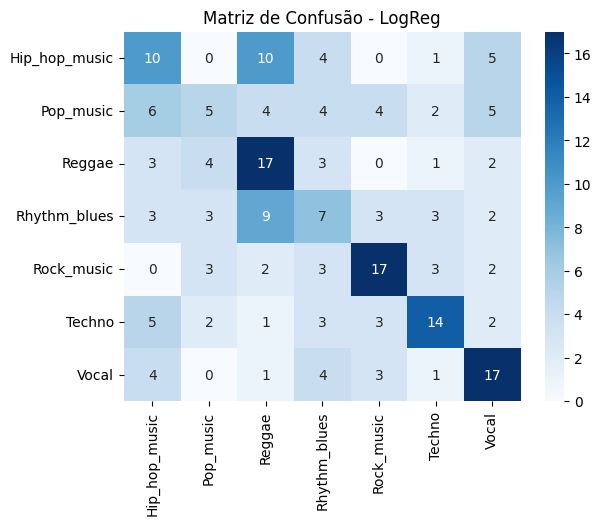

RF: acc=0.381, prec=0.380, rec=0.381, f1=0.375


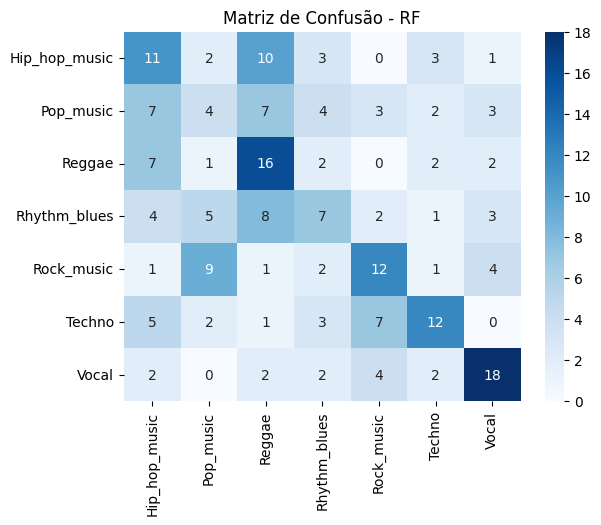

SVM: acc=0.457, prec=0.439, rec=0.457, f1=0.438


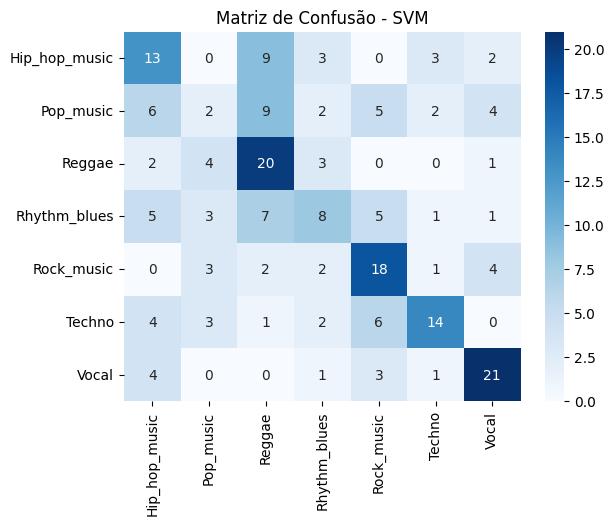

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:36:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB: acc=0.390, prec=0.387, rec=0.390, f1=0.385


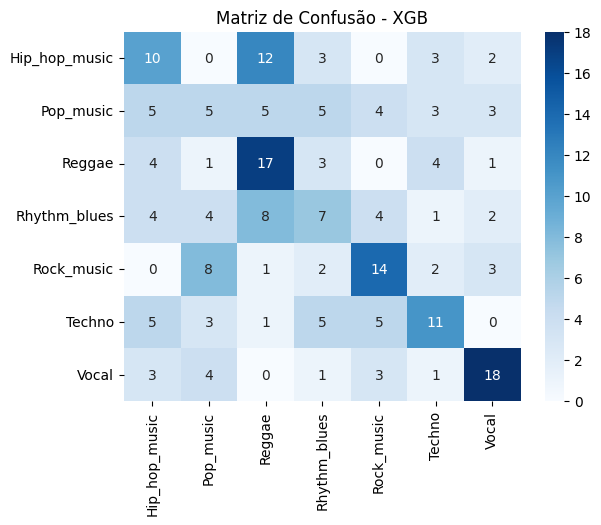

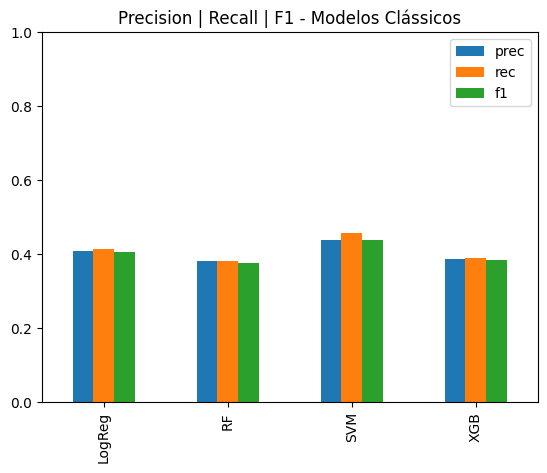

In [ ]:
# ==========================
# ETAPA 7 – FEATURE EXTRACTION + MODELOS CLÁSSICOS (REVISADO)
# ==========================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score
import seaborn as sns


feats, labels = [], []
for f in tqdm(os.listdir(WAV_DIR)):
    if not f.endswith(".wav"): continue
    try:
        label = f.split("_",1)[1][:-4]
        y, sr = librosa.load(os.path.join(WAV_DIR,f), sr=22050)
        feat=[]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20); feat.extend(np.mean(mfcc,axis=1)); feat.extend(np.std(mfcc,axis=1))
        chroma = librosa.feature.chroma_stft(y=y, sr=sr); feat.extend(np.mean(chroma,axis=1)); feat.extend(np.std(chroma,axis=1))
        sc = librosa.feature.spectral_centroid(y=y, sr=sr); feat.extend([np.mean(sc), np.std(sc)])
        ro = librosa.feature.spectral_rolloff(y=y, sr=sr); feat.extend([np.mean(ro), np.std(ro)])
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr); feat.extend(np.mean(contrast,axis=1)); feat.extend(np.std(contrast,axis=1))
        zcr = librosa.feature.zero_crossing_rate(y); feat.extend([np.mean(zcr), np.std(zcr)])
        rmse = librosa.feature.rms(y=y); feat.extend([np.mean(rmse), np.std(rmse)])
        feats.append(feat); labels.append(label)
    except:
        pass

df_feats = pd.DataFrame(feats); df_feats["label"]=labels
X = df_feats.drop("label",axis=1).values
y_text = df_feats["label"].values
le = LabelEncoder(); y = le.fit_transform(y_text)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

models_dict = {
    "LogReg": LogisticRegression(max_iter=2000),
    "RF": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
}

results = {}
for name,clf in models_dict.items():
    if name in ["LogReg","SVM"]:
        clf.fit(X_train_s,y_train); preds=clf.predict(X_test_s); probs=clf.predict_proba(X_test_s)
    else:
        clf.fit(X_train,y_train); preds=clf.predict(X_test); probs=clf.predict_proba(X_test)
    acc=accuracy_score(y_test,preds); prec=precision_score(y_test,preds,average="macro"); rec=recall_score(y_test,preds,average="macro"); f1=f1_score(y_test,preds,average="macro")
    results[name]={"acc":acc,"prec":prec,"rec":rec,"f1":f1}
    print(f"{name}: acc={acc:.3f}, prec={prec:.3f}, rec={rec:.3f}, f1={f1:.3f}")
    cm=confusion_matrix(y_test,preds)
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=le.classes_,yticklabels=le.classes_)
    plt.title(f"Matriz de Confusão - {name}"); plt.show()

res_df = pd.DataFrame(results).T
res_df[["prec","rec","f1"]].plot(kind="bar")
plt.title("Precision | Recall | F1 - Modelos Clássicos"); plt.ylim(0,1); plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:39:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


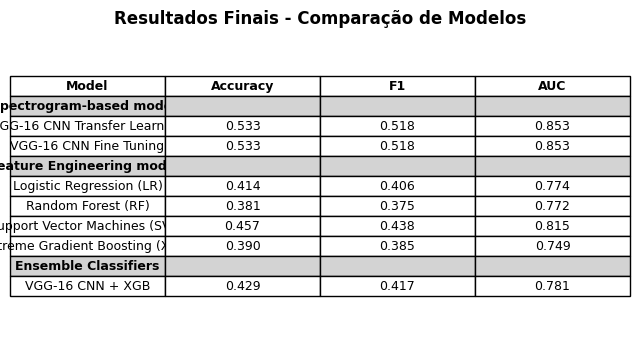

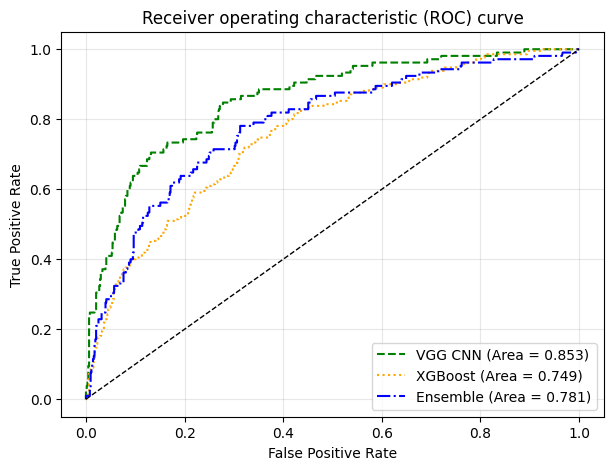

In [ ]:
# ==========================
# ETAPA 8 – COMPARAÇÃO FINAL (COM TABELA GERADA COMO IMAGEM + ROC DOS 3 PRINCIPAIS)
# ==========================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# A) ---- Garantir que as predições da CNN (transfer) e CNN fine-tuned existam ----
pred_probs = model.predict(
    batch_generator(test_files, test_labels, shuffle=False),
    steps=len(test_files)//BATCH_SIZE + 1,
    verbose=1
)[:len(test_files)]
preds = np.argmax(pred_probs, axis=1)

pred_probs_ft = model.predict(
    batch_generator(test_files, test_labels, shuffle=False),
    steps=len(test_files)//BATCH_SIZE + 1,
    verbose=1
)[:len(test_files)]
preds_ft = np.argmax(pred_probs_ft, axis=1)

# B) ---- Extrair embeddings e treinar (ou re-treinar) o XGBoost de ensemble ----
# (Se você já treinou o clf_xgb antes, isto apenas re-treina com os embeddings atuais; é seguro)
extractor = models.Model(inputs=model.input, outputs=model.layers[-2].output)

X_train_emb = extractor.predict(
    batch_generator(train_files, train_labels, shuffle=False),
    steps=len(train_files)//BATCH_SIZE + 1,
    verbose=1
)[:len(train_files)]

X_test_emb = extractor.predict(
    batch_generator(test_files, test_labels, shuffle=False),
    steps=len(test_files)//BATCH_SIZE + 1,
    verbose=1
)[:len(test_files)]

clf_xgb_ens = xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
clf_xgb_ens.fit(X_train_emb, train_labels)
preds_xgb_ens = clf_xgb_ens.predict(X_test_emb)
probs_xgb_ens = clf_xgb_ens.predict_proba(X_test_emb)

# C) ---- Métricas das CNNs e do ensemble ----
cnn_metrics = {
    "Accuracy": accuracy_score(test_labels, preds),
    "F1": f1_score(test_labels, preds, average="macro"),
    "AUC": roc_auc_score(label_binarize(test_labels, classes=np.arange(num_classes)), pred_probs, average="macro")
}
cnn_ft_metrics = {
    "Accuracy": accuracy_score(test_labels, preds_ft),
    "F1": f1_score(test_labels, preds_ft, average="macro"),
    "AUC": roc_auc_score(label_binarize(test_labels, classes=np.arange(num_classes)), pred_probs_ft, average="macro")
}
cnn_xgb_metrics = {
    "Accuracy": accuracy_score(test_labels, preds_xgb_ens),
    "F1": f1_score(test_labels, preds_xgb_ens, average="macro"),
    "AUC": roc_auc_score(label_binarize(test_labels, classes=np.arange(num_classes)), probs_xgb_ens, average="macro")
}

# D) ---- Métricas dos modelos clássicos (garante probs para AUC) ----
classic_results = {}
for name, clf in models_dict.items():
    try:
        # Escolhe as features corretas conforme seu fluxo anterior
        if name in ["LogReg", "SVM"]:
            X_eval = X_test_s
            y_eval = y_test
        else:
            X_eval = X_test
            y_eval = y_test

        preds_c = clf.predict(X_eval)
        # tenta obter probabilidades
        if hasattr(clf, "predict_proba"):
            probs_c = clf.predict_proba(X_eval)
        else:
            # fallback: se tiver decision_function, tenta converter (não ideal para multiclass)
            if hasattr(clf, "decision_function"):
                dfc = clf.decision_function(X_eval)
                # if shape (n_samples,) => binary; if (n_samples,n_classes) => ok
                if dfc.ndim == 1:
                    # transforma em 2-colunas via softmax-like
                    probs_c = np.vstack([1 - 1/(1+np.exp(dfc)), 1/(1+np.exp(dfc))]).T
                else:
                    # aplica softmax por linha
                    exp = np.exp(dfc - np.max(dfc, axis=1, keepdims=True))
                    probs_c = exp / exp.sum(axis=1, keepdims=True)
            else:
                probs_c = None

        # calcula métricas
        acc = accuracy_score(y_eval, preds_c)
        f1v = f1_score(y_eval, preds_c, average="macro")
        if probs_c is not None:
            y_bin = label_binarize(y_eval, classes=np.arange(len(le.classes_)))
            auc = roc_auc_score(y_bin, probs_c, average="macro")
        else:
            auc = np.nan

        classic_results[name] = {"Accuracy": acc, "F1": f1v, "AUC": auc, "probs": probs_c}
    except Exception as e:
        # em caso de erro, registra NaNs para não quebrar o bloco
        classic_results[name] = {"Accuracy": np.nan, "F1": np.nan, "AUC": np.nan, "probs": None}
        print(f"Warning computing metrics for {name}: {e}")

# E) ---- Consolidar tudo em um DataFrame (ordem e nomes como no artigo) ----
rows = []
# Spectrogram block
rows.append(["Spectrogram-based models", "", "", ""])
rows.append(["VGG-16 CNN Transfer Learning",
             cnn_metrics["Accuracy"], cnn_metrics["F1"], cnn_metrics["AUC"]])
rows.append(["VGG-16 CNN Fine Tuning",
             cnn_ft_metrics["Accuracy"], cnn_ft_metrics["F1"], cnn_ft_metrics["AUC"]])
# Feature engineering block
rows.append(["Feature Engineering models", "", "", ""])
rows.append(["Logistic Regression (LR)",
             classic_results.get("LogReg", {}).get("Accuracy", np.nan),
             classic_results.get("LogReg", {}).get("F1", np.nan),
             classic_results.get("LogReg", {}).get("AUC", np.nan)])
rows.append(["Random Forest (RF)",
             classic_results.get("RF", {}).get("Accuracy", np.nan),
             classic_results.get("RF", {}).get("F1", np.nan),
             classic_results.get("RF", {}).get("AUC", np.nan)])
rows.append(["Support Vector Machines (SVM)",
             classic_results.get("SVM", {}).get("Accuracy", np.nan),
             classic_results.get("SVM", {}).get("F1", np.nan),
             classic_results.get("SVM", {}).get("AUC", np.nan)])
rows.append(["Extreme Gradient Boosting (XGB)",
             classic_results.get("XGB", {}).get("Accuracy", np.nan),
             classic_results.get("XGB", {}).get("F1", np.nan),
             classic_results.get("XGB", {}).get("AUC", np.nan)])
# Ensemble block
rows.append(["Ensemble Classifiers", "", "", ""])
rows.append(["VGG-16 CNN + XGB",
             cnn_xgb_metrics["Accuracy"], cnn_xgb_metrics["F1"], cnn_xgb_metrics["AUC"]])

df_table = pd.DataFrame(rows, columns=["Model", "Accuracy", "F1", "AUC"])

# F) ---- Plotar a tabela como imagem, com blocos destacados ----
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")

table = ax.table(cellText=df_table.values,
                 colLabels=df_table.columns,
                 cellLoc="center",
                 loc="center")

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.2)

# Destacar as linhas de bloco
# Procura por células cujo texto é o nome do bloco e pinta a linha
block_labels = ["Spectrogram-based models", "Feature Engineering models", "Ensemble Classifiers"]
for r, row in enumerate(df_table["Model"].values):
    if row in block_labels:
        # a primeira linha do table corresponde ao cabeçalho, então os dados começam em row+1
        for c in range(len(df_table.columns)):
            cell = table[(r+1, c)]
            cell.set_facecolor("#d3d3d3")
            cell.get_text().set_weight("bold")

# Formatar números (as células já têm strings/numeros), ajustar alinhamento
for (r, c), cell in table.get_celld().items():
    # cabeçalho
    if r == 0:
        cell.get_text().set_weight("bold")
    else:
        # mantém decimal com 3 casas para floats
        val = df_table.values[r-1, c] if r-1 >= 0 else ""
        if isinstance(val, float) and not np.isnan(val):
            cell.get_text().set_text(f"{val:.3f}")
        elif isinstance(val, float) and np.isnan(val):
            cell.get_text().set_text("NaN")

plt.title("Resultados Finais - Comparação de Modelos", fontsize=12, weight="bold")
plt.show()

# (Opcional) salvar figura
# fig.savefig("results_table.png", dpi=300, bbox_inches="tight")

# G) ---- Curvas ROC: apenas CNN, XGB clássico e Ensemble ----
plt.figure(figsize=(7,5))
y_true_bin = label_binarize(test_labels, classes=np.arange(num_classes))

# CNN ROC
fpr_cnn, tpr_cnn, _ = roc_curve(y_true_bin.ravel(), pred_probs.ravel())
auc_cnn = roc_auc_score(y_true_bin, pred_probs, average="macro")
plt.plot(fpr_cnn, tpr_cnn, linestyle="--", color="green", label=f"VGG CNN (Area = {auc_cnn:.3f})")

# XGB clássico ROC (se disponível)
probs_xgb_classic = classic_results.get("XGB", {}).get("probs", None)
if probs_xgb_classic is None:
    # tenta recalcular a probabilidade do modelo XGB clássico diretamente (fallback)
    try:
        probs_xgb_classic = models_dict["XGB"].predict_proba(X_test)
    except Exception:
        probs_xgb_classic = None

if probs_xgb_classic is not None:
    y_bin_classic = label_binarize(y_test, classes=np.arange(len(le.classes_)))
    fpr_xgb, tpr_xgb, _ = roc_curve(y_bin_classic.ravel(), probs_xgb_classic.ravel())
    auc_xgb = roc_auc_score(y_bin_classic, probs_xgb_classic, average="macro")
    plt.plot(fpr_xgb, tpr_xgb, linestyle=":", color="orange", label=f"XGBoost (Area = {auc_xgb:.3f})")
else:
    print("Aviso: probabilidades do XGB clássico não estão disponíveis. XGB não será mostrado na ROC.")

# Ensemble ROC (CNN embeddings -> XGB ensemble)
fpr_ens, tpr_ens, _ = roc_curve(y_true_bin.ravel(), probs_xgb_ens.ravel())
auc_ens = roc_auc_score(y_true_bin, probs_xgb_ens, average="macro")
plt.plot(fpr_ens, tpr_ens, linestyle="-.", color="blue", label=f"Ensemble (Area = {auc_ens:.3f})")

# Ajustes finais
plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic (ROC) curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


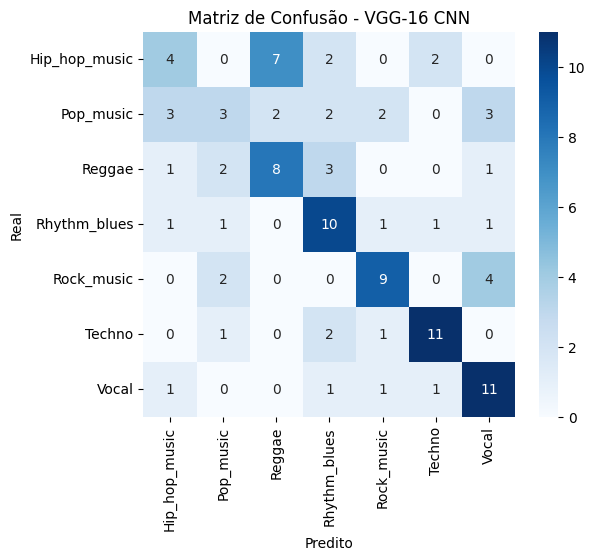

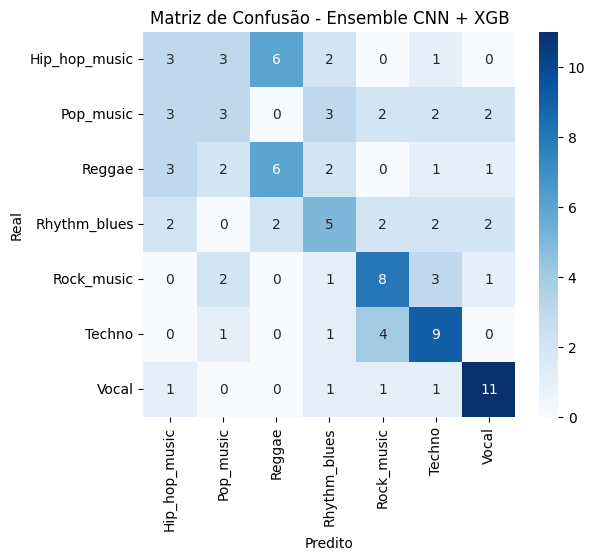

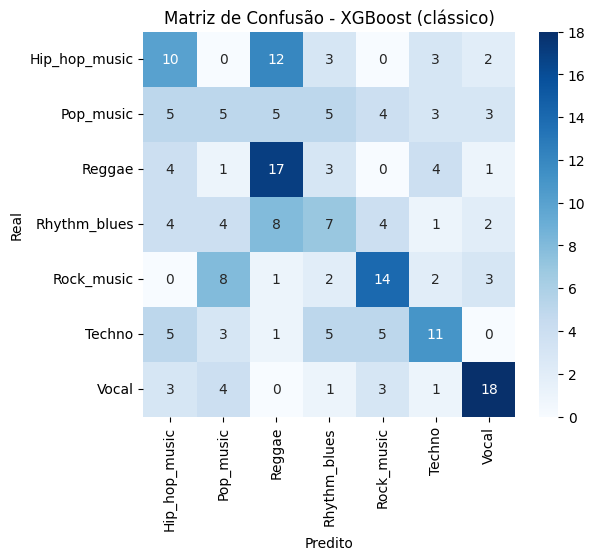

In [ ]:
# ==========================
# ETAPA 9 – MATRIZES DE CONFUSÃO (CNN, CNN+XGB, XGB CLÁSSICO)
# ==========================

import seaborn as sns
from sklearn.metrics import confusion_matrix

# CNN
cm_cnn = confusion_matrix(test_labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão - VGG-16 CNN")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# CNN + XGB (ensemble)
cm_ens = confusion_matrix(test_labels, preds_xgb_ens)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ens, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão - Ensemble CNN + XGB")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# XGB clássico (feature engineering)
preds_xgb_classic = models_dict["XGB"].predict(X_test)
cm_xgb = confusion_matrix(y_test, preds_xgb_classic)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de Confusão - XGBoost (clássico)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()
